In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
K_H=3e-2 # M atm-1
K_1=9e-7 # M
K_2=7e-10 # M
pCO2 = np.array([0.002, 0.005, 0.01, 0.02, 0.05, 0.1], dtype=float)  # atm (≈bar)
pH   = np.array([6.0, 7.0, 8.0, 8.2], dtype=float)
Hplus = 10**(-pH)  # M

In [3]:
# Compute [CO2(aq)] for each pH (rows) and pCO2 (cols)
factor = 1 + (K_1 / Hplus)[:, None] + (K_1 * K_2 / (Hplus**2))[:, None]
CO2aq  = K_H * pCO2[None, :] * factor

# Heatmap (log10 for dynamic range)
logCO2aq = np.log10(CO2aq)


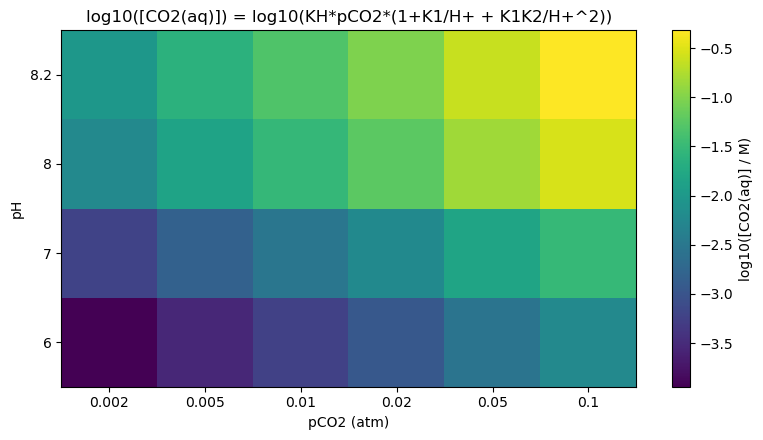

In [4]:
plt.figure(figsize=(8, 4.5))
im = plt.imshow(logCO2aq, aspect='auto', origin='lower')
plt.colorbar(im, label='log10([CO2(aq)] / M)')
plt.xticks(np.arange(len(pCO2)), [f"{v:g}" for v in pCO2])
plt.yticks(np.arange(len(pH)), [f"{v:g}" for v in pH])
plt.xlabel('pCO2 (atm)')
plt.ylabel('pH')
plt.title('log10([CO2(aq)]) = log10(KH*pCO2*(1+K1/H+ + K1K2/H+^2))')
plt.tight_layout()
plt.show()


In [ ]:
V_ocean=1.4e21  # liters
MCO2aq=CO2aq*V_ocean  # moles of dissolved CO2 in ocean at various pH and pCO2
print(MCO2aq) #mol

[[1.59652920e+17 3.99132300e+17 7.98264600e+17 1.59652920e+18
  3.99132300e+18 7.98264600e+18]
 [8.45292000e+17 2.11323000e+18 4.22646000e+18 8.45292000e+18
  2.11323000e+19 4.22646000e+19]
 [8.17320000e+18 2.04330000e+19 4.08660000e+19 8.17320000e+19
  2.04330000e+20 4.08660000e+20]
 [1.33950828e+19 3.34877071e+19 6.69754142e+19 1.33950828e+20
  3.34877071e+20 6.69754142e+20]]


In [6]:
# assume atmosphere 1atm, mol the same as PAL
N_a = 1.8e20
MCO2air = N_a * pCO2
M_total = MCO2aq + MCO2air[None, :]
F_air = MCO2air[None, :] / M_total



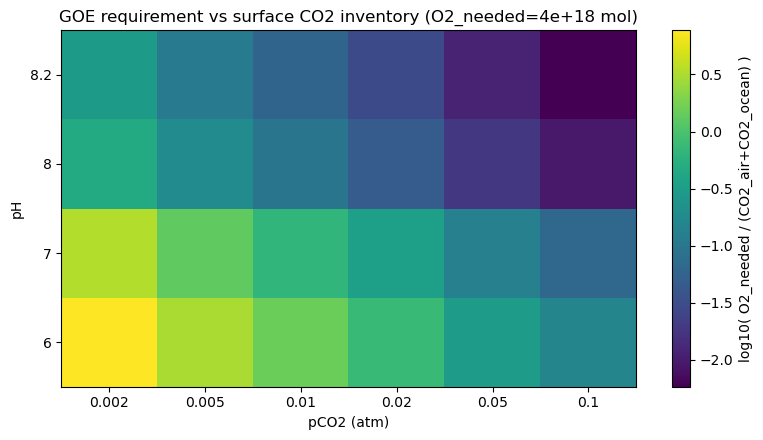

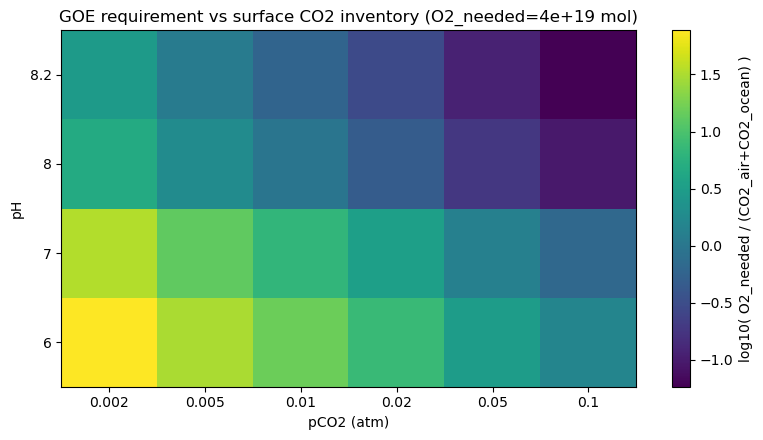

In [9]:
# GOE O2 targets (mol)
O2_targets = [4e18, 4e19] #0.1 PAL, 1 PAL

# Plot heatmaps of log10( O2_needed / total_CO2_inventory )
for O2 in O2_targets:
    ratio = O2 / M_total
    logr = np.log10(ratio)
    plt.figure(figsize=(8,4.5))
    im = plt.imshow(logr, aspect='auto', origin='lower')
    plt.colorbar(im, label='log10( O2_needed / (CO2_air+CO2_ocean) )')
    plt.xticks(np.arange(len(pCO2)), [f"{v:g}" for v in pCO2])
    plt.yticks(np.arange(len(pH)), [f"{v:g}" for v in pH])
    plt.xlabel('pCO2 (atm)')
    plt.ylabel('pH')
    plt.title(f'GOE requirement vs surface CO2 inventory (O2_needed={O2:.0e} mol)')
    plt.tight_layout()
    plt.show()


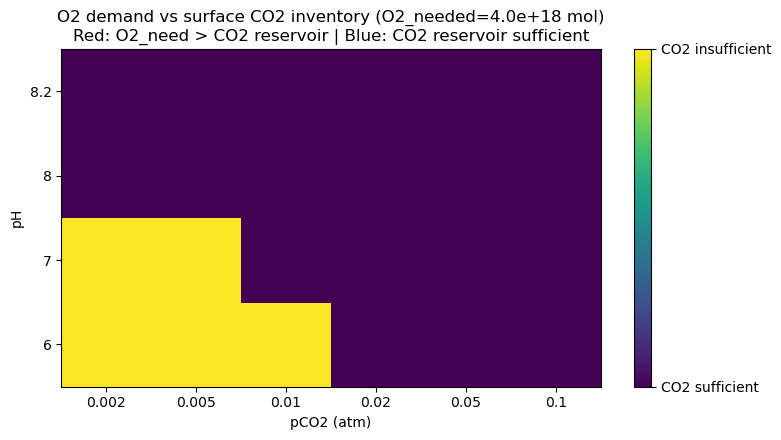

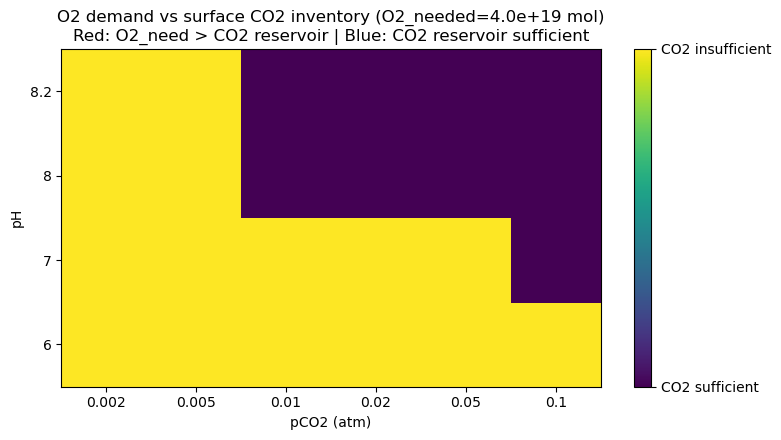

In [10]:
O2_targets = [4e18, 4e19]  # 0.1 PAL, 1 PAL

for O2 in O2_targets:
    # Boolean mask: True where O2_needed > total CO2 inventory
    mask = O2 > M_total

    # Convert to int for plotting (1 = red, 0 = blue)
    plot_data = mask.astype(int)

    plt.figure(figsize=(8, 4.5))
    im = plt.imshow(plot_data, aspect='auto', origin='lower',
                    vmin=0, vmax=1)
    cbar = plt.colorbar(im, ticks=[0, 1])
    cbar.ax.set_yticklabels(['CO2 sufficient', 'CO2 insufficient'])

    plt.xticks(np.arange(len(pCO2)), [f"{v:g}" for v in pCO2])
    plt.yticks(np.arange(len(pH)), [f"{v:g}" for v in pH])
    plt.xlabel('pCO2 (atm)')
    plt.ylabel('pH')
    plt.title(f'O2 demand vs surface CO2 inventory (O2_needed={O2:.1e} mol)\n'
              'Red: O2_need > CO2 reservoir | Blue: CO2 reservoir sufficient')

    plt.tight_layout()
    plt.show()